In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [6]:
import glob 

noisy_files = glob.glob("./images/noisy/*")
imgs = glob.glob("./images/*")

len(imgs)

15

#### Task 1:
1. Apply histogram equalization to an image and observe the effect on contrast.
2. Compare the histograms before and after equalization.
3. Discuss why histogram equalization improves contrast in images with poor lighting.

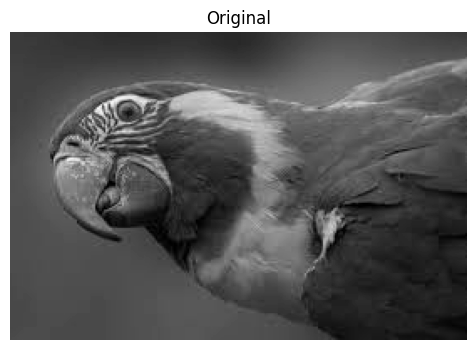

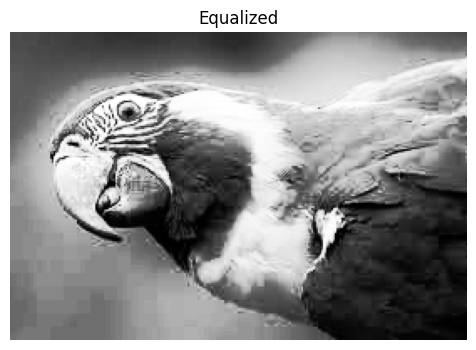

In [10]:
img1 = cv2.imread(imgs[0], 0)
eq1 = cv2.equalizeHist(img1)
from utils import show

show(img1, "Original", cmap="gray")
show(eq1, "Equalized", cmap="gray")

Task 2:
1. Apply a Gaussian filter to the image using cv2.GaussianBlur().
2. Experiment with different kernel sizes (e.g., 3x3, 5x5) and sigma values.
3. Compare the results to those from the box filter and describe the differences.
4. Display all results side by side.

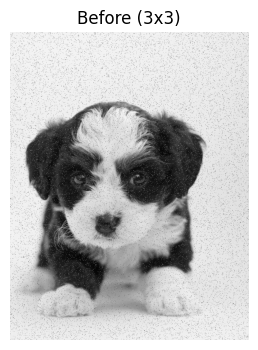

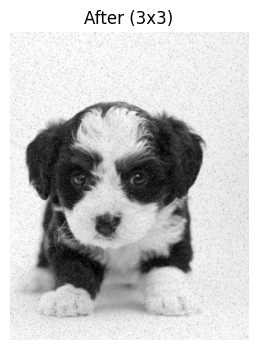

In [18]:
img2 = cv2.imread(noisy_files[0], 0)

gs_img = cv2.GaussianBlur(img2,(3, 3), 1)

show(img2, title="Before (3x3)", cmap='gray')
show(gs_img, title="After (3x3)", cmap='gray')

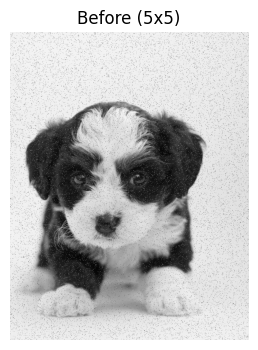

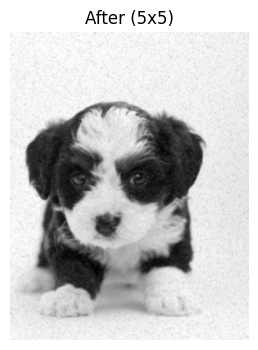

In [21]:
img2 = cv2.imread(noisy_files[0], 0)

gs_img = cv2.GaussianBlur(img2,(5, 5), 5)

show(img2, title="Before (5x5)", cmap='gray')
show(gs_img, title="After (5x5)", cmap='gray')

Task 3:
1. Apply Gaussian blur to the image as part of unsharp masking.
2. Subtract the blurred image from the original to highlight edges.
3. Combine the original and edge-highlighted image using addWeighted().
4. Adjust the weighting to see different sharpness levels.



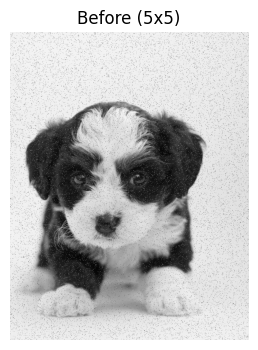

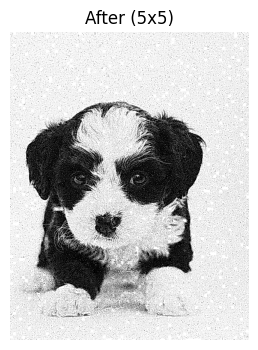

In [30]:
blurred = cv2.GaussianBlur(img2, (5, 5), 7)
res = img2 - blurred
unsharp_img = cv2.addWeighted(img2, 1.5, res, -0.5, 0)
show(img2, title="Before (5x5)", cmap='gray')
show(unsharp_img, title="After (5x5)", cmap='gray')

##### Task 4:
1. Using the source code provided above, use various combinations of parameters filt_size
and k and write down the impact of their variations. Use various filt_size such as 3, 5, 7,
9, 11, 15 as well as various values of k such as -2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9

In [38]:
def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")

    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))

    image_padded = np.pad(image_input,
    pad_width=((pad_size,pad_size),(pad_size,
    pad_size)), mode='symmetric')

    image_box = image_input.copy()

    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    
    return image_box


def task_4(image_input, filt_size, k, plot:bool=True):

    image_input = image_input.astype('float32')/255

    box = box_filt(filt_size)
    image_blur = apply_filters(image_input, box,filt_size)
    image_diff = image_input - image_blur
    image_sharp = image_input+k*image_diff
    
    if plot:
        show(image_sharp, title=f'Filt_size={filt_size} & k={k}')

    return image_sharp


filt_sizes = [3, 5, 7,9, 11, 15 ]
ks = [ -2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9]

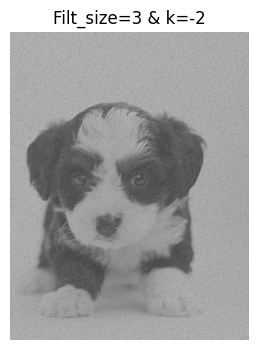

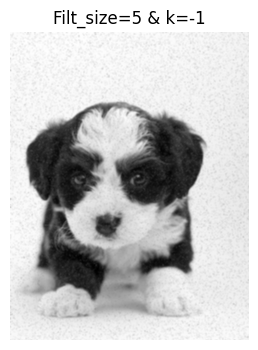

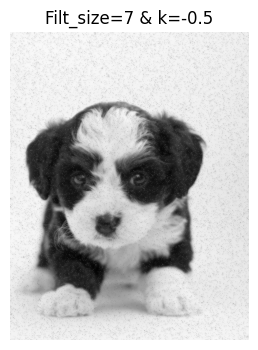

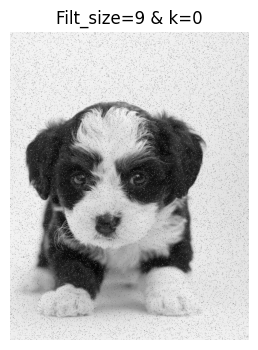

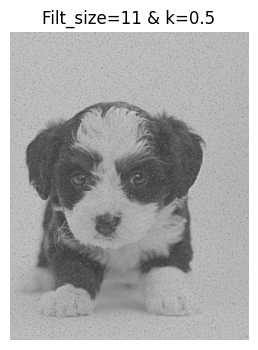

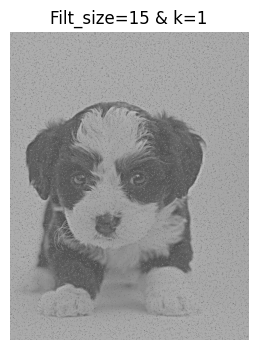

In [39]:
results = [task_4(img2, f, k) for f, k in zip(filt_sizes, ks[:6])]
